# 1D AMT Synthetic Inversions (Halfspace + Layered + Position Change)

In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Reading Synthetic Data Files From Forward Model

In [2]:
dobs = np.load("Forward_Data/Observed_Forward_Model_Data_Original.npy")
dpred = np.load("Forward_Data/Observed_Forward_Model_Data_Reshaped.npy")

### Defining Halfspace Mesh + Starting Model + Map

In [3]:
# Defining Mesh for Halfspace
layer_thick_halfspace = [1000]
n_layers_halfspace = 1
rho = 500

# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/500) * np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


### Bringing in used Frequencies and Geological Details

In [4]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data
#sigma = 1/np.r_[500.,500., 500., 500.,500,500,500]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304


### Setting up Simulation

In [5]:
#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=[],
        sigmaMap=conductivity_halfspace_map
    )

# ### Using this, I get: NotImplementedError: The getJ method hasn't been implemented for the Simulation1DElectricField yet.
# simulation_hsp = nsem.Simulation1DElectricField(mesh,
#     survey=survey, 
#     sigmaMap=conductivity_halfspace_map,
#     solver = Mumps)


### This error is probably being thrown due to the use of update_jacobi in the directives list below

### Viewing Data

`dobs_new` is created because the forward model simulation and the inversion simulation objects are different. They both take the data differently. Here we are setting it up for the `Simulation1DRecursive` simulation object and then viewing it.

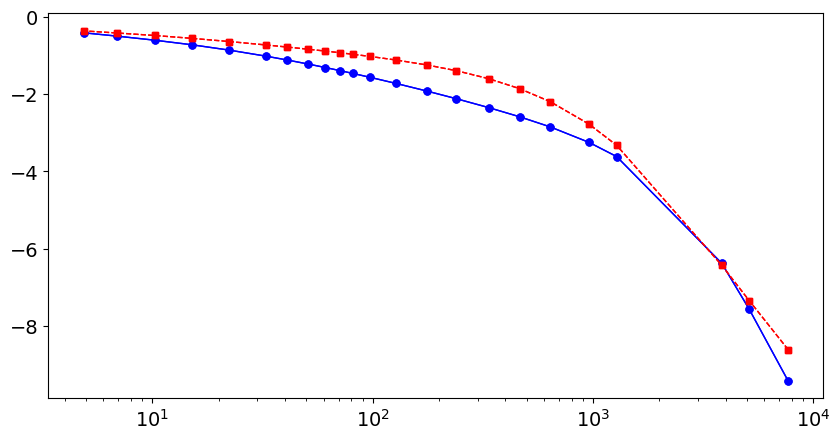

In [6]:
dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row


real_data_new = dobs_new.reshape(len(frequencies),4) # Reshaping to 23 rows and 4 columns

fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,0], "b-o", lw=1, ms=5, label = 'XY Real- Real')
ax.semilogx(frequencies, real_data_new[:,2], "b-o", lw=1, ms=5, label = 'YX Real - Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,1], "r--s", lw=1, ms=5, label = 'XY Imag - Real')
ax.semilogx(frequencies, real_data_new[:,3], "r--s", lw=1, ms=5, label = 'YX Imag - Real')

plt.show()

### Data Misfit

In [7]:
#uncertainties = 0.05 * np.abs(dobs) * np.ones(np.shape(dobs))
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

In [8]:

h = np.r_[layer_thick_halfspace]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([h], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 1
reg_L2.alpha_x= 5



### Optimization

In [9]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

In [10]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Halfspace Inversion!

In [11]:
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_hsp = conductivity_halfspace_map * recovered_halfspace_model_L2

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.38e+00  1.53e+04  0.00e+00  1.53e+04                                 
   1  6.38e+00  1.07e+04  2.87e+02  1.26e+04    8.20e+03      0              
   2  6.38e+00  9.80e+03  4.14e+02  1.24e+04    1.84e+03      0              
   3  6.38e+00  9.59e+03  4.47e+02  1.24e+04    4.39e+02      0              
   4  2.55e+00  5.36e+03  1.41e+03  8.95e+03    5.22e+03      0              
   5  2.55e+00  4.66e+03  1.65e+03  8.87e+03    1.32e+03      0              
   6  2.55e+00  4.51e+03  1.70e+03  8.86e+03    3.07e+02      0              
   7  1.02e+00  2.61e+03  2.76e+03  5.42e+03    4.07e+03      0              
   8  1.02e+00  2.54e+03  2.82e+03  5.42e+03    2.82e+02      0              
   9  1.02e+00  2.54e+03

### Results!

In [12]:
print("Conductivity halfspace: ", conductivities_hsp)
print("Resistivity halfspace: ", 1/conductivities_hsp)
rho_hsp_pred = 1/conductivities_hsp

Conductivity halfspace:  [0.00030498]
Resistivity halfspace:  [3278.89163418]


### Moving to a Multi-Layered Inversion using the recovered halfspace results as m0

In [13]:
# Defining Mesh for 7 layers
layer_thick = np.array([25, 180, 85, 125, 65, 70])   #m
rho = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.] #ohm-m
n_layers_halfspace = len(rho)


# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=layer_thick,
        sigmaMap=conductivity_halfspace_map
    )

dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row



### Data Misfit
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

h = np.r_[layer_thick]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 1
reg_L2.alpha_x= 5


### Optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Inversion !!!
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_ml = conductivity_halfspace_map * recovered_halfspace_model_L2




INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.22e+02  2.12e+03  0.00e+00  2.12e+03                                 
   1  6.22e+02  1.00e+03  5.82e-01  1.37e+03    3.21e+03      0              
   2  6.22e+02  9.17e+02  7.06e-01  1.36e+03    3.88e+02      0              
   3  6.22e+02  9.06e+02  7.22e-01  1.36e+03    4.42e+01      0              
   4  2.49e+02  5.37e+02  1.61e+00  9.38e+02    1.17e+03      0              
   5  2.49e+02  5.00e+02  1.75e+00  9.35e+02    1.76e+02      0              
   6  2.49e+02  4.96e+02  1.76e+00  9.35e+02    2.13e+01      0              
   7  9.96e+01  2.85e+02  3.02e+00  5.85e+02    7.62e+02      0              
   8  9.96e+01  2.64e+02  3.20e+00  5.83e+02    1.23e+02      0              
   9  9.96e+01  2.62e+02

In [14]:
np.round(1/conductivities_ml[::-1]), 1/sigma

(array([2590., 2659., 2422., 2015., 1909., 3797., 8395.]),
 array([ 2000.,  2500.,  4000.,  4500.,  8000.,   500., 10000.]))

Text(0.5, 1.0, 'Depth vs. Sigma')

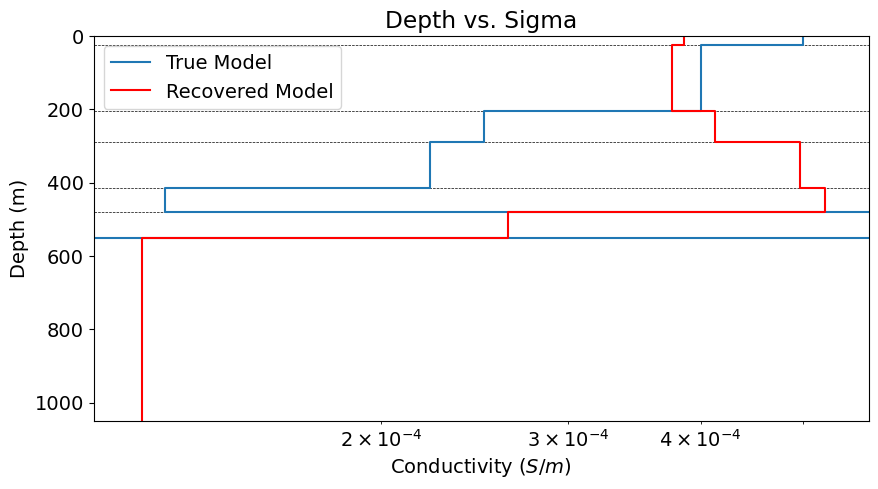

In [15]:
#Plotting True Vs recovered
fig , ax= plt.subplots(1,1,figsize=(10, 5))
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax, show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, conductivities_ml[::-1],c = 'r', label = 'Recovered Model', ax = ax)
#ax.grid(which="both")
ax.legend()
ax.set_xlabel(r"Conductivity ($S/m$)")
ax.set_title('Depth vs. Sigma')

### Testing Area (Dangerous!!!):

In [16]:
# dobs = dobs
# standard_deviation = 0.5
# rho_0 = 2000
# rho_ref = 2500
# maxIter=10
# maxIterCG=30
# maxIterLS=30
# alpha_s=1e-10
# alpha_z=1
# beta0_ratio=1
# coolingFactor = 2
# coolingRate=1
# chi_factor=1
# p_s=0
# p_z=0

In [17]:
#Defining inversion function
dobs = dobs
standard_deviation = 0.5
rho_0 = 2000
rho_ref = 2500
maxIter=10
maxIterCG=30
maxIterLS=30
alpha_s=1e-10
alpha_z=1
beta0_ratio=1
coolingFactor = 2
coolingRate=1
chi_factor=1
p_s=0
p_z=0

layer_thicknesses_inv = layer_thicknesses[:6] # Layers without halfspace

n_layer = len(layer_thicknesses_inv) + 1 # Total Number of Layers + halfspace

mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")

sigma_map = maps.ExpMap(nP = n_layer)
    
simulation = nsem.simulation_1d.Simulation1DRecursive(
    survey=survey, 
    sigmaMap=sigma_map,
    thicknesses=layer_thicknesses_inv,
)
# Define the data 
data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    

# Initial model
m0 = np.ones(n_layer) * np.log(1./rho_0)

# Reference model
mref = np.ones(n_layer) * np.log(1./rho_ref)    

dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

# Define the regularization (model objective function)
reg = regularization.Sparse(
    mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, 
    reference_model=mref,
    reference_model_in_smooth=False,
    mapping=maps.IdentityMap(nP = n_layer),
)

# Define how the optimization problem is solved. Here we will use an inexact
# Gauss-Newton approach that employs the conjugate gradient solver.
opt = optimization.InexactGaussNewton(
maxIter=maxIter,
maxIterCG=maxIterCG,
maxIterLS=maxIterLS,
)


# Define the inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

#######################################################################
# Define Inversion Directives
# ---------------------------
#
# Here we define any directives that are carried out during the inversion. This
# includes the cooling schedule for the trade-off parameter (beta), stopping
# criteria for the inversion and saving inversion results at each iteration.
#

# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

# Set the rate of reduction in trade-off parameter (beta) each time the
# the inverse problem is solved. And set the number of Gauss-Newton iterations
# for each trade-off paramter value.
beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
save_dictionary = directives.SaveOutputDictEveryIteration()
save_dictionary.outDict = {}
# Setting a stopping criteria for the inversion.
target_misfit = directives.TargetMisfit(chifact=chi_factor)
precond = directives.UpdatePreconditioner()

# The directives are defined as a list.
directives_list = [
    precond,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_dictionary
]

#####################################################################
# Running the Inversion
# ---------------------
#
# To define the inversion object, we need to define the inversion problem and
# the set of directives. We can then run the inversion.
#

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Run the inversion
recovered_model = inv.run(m0)    
output_dict= save_dictionary.outDict
#return recovered_model, 

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  4.80e+03  6.43e+03  3.09e-09  6.43e+03                                 
   1  4.80e+03  4.16e+03  4.66e-03  4.18e+03    1.45e+03      0              
   2  2.40e+03  3.79e+03  9.72e-03  3.81e+03    3.48e+02      0              
   3  1.20e+03  3.74e+03  4.44e-05  3.74e+03    6.32e+01      0              
   4  6.00e+02  3.73e+03  3.94e-06  3.73e+03    7.95e+00      0              
   5  3.00e+02  3.73e+03  6.16e-06  3.73e+03    1.17e+00      0              
   6  1.50e+02  3.73e+03  8.88e-06  3.73e+03    1.58e-01      0              
   7  7.51e+01  3.73e+03  1.21e-05  3.73e+03    2.13e-02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.8730e-02 <= tolF*(1+|f0|) 

In [18]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

In [19]:
matplotlib.rcParams['font.size'] = 14
def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds)
    ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro')
    ax.set_xlabel(r"$\phi_m$")
    ax.set_ylabel(r"$\phi_d$")
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')
    ax.set_title("Iteration={:d}, Beta = {:.1e}".format(iteration, betas[iteration-1]))
    ax.set_xlim(xlim)
    plt.show()

In [20]:
# #Plotting
# iteration = 5
# dpred = output_dict[iteration]['dpred']
# m = output_dict[iteration]['m']
# fig = plt.figure(figsize=(16, 5))
# gs = gridspec.GridSpec(1, 5, figure=fig)

# ax0 = fig.add_subplot(gs[0, 0])
# plot_1d_layer_model(layer_thicknesses, 1/sigma) # figure has base value at log plot
# plot_1d_layer_model(
#     layer_thicknesses_inv,
#     1.0 / np.exp(m),
#     ax=ax0,
#     color="k",
#     label=r"$m_{Inv}$",
#     linestyle="--",
# )
# ax0.legend()
# ax0.set_xlabel(r"Resistivity [$\Omega$m]")
# ax0.set_title('Model from iteration ' + str(iteration), fontsize=14)
# ax0.grid(True, which='both', alpha=0.5)


# ax = fig.add_subplot(gs[0, 2:])
# ax.loglog(1./frequencies, dpred.reshape((len(frequencies), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

# ax_1 = ax.twinx()
# ax_1.plot(1./frequencies, dpred.reshape((len(frequencies), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
# ax.set_xlabel("Period [s]")
# ax.grid(True, which='both', alpha=0.5)
# ax.set_ylabel(r"Apparent resistivity [$\Omega$m]")
# ax_1.set_ylabel(r"Phase [$\degree$]")
# # ax.legend(bbox_to_anchor=(1.1,1))
# ax.legend(loc=2)
# ax_1.legend(loc=1)
# plt.show()

In [21]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

interactive(children=(IntSlider(value=7, description='iteration', max=7, min=1), RadioButtons(description='sca…